<a href="https://colab.research.google.com/github/Archi-shaw/Deep-Learning/blob/main/Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Data (prepare and load)
2. build model
3. Fitting the  model to data (training)
4. Making predictions and evaluating a model (inference)
5. Saving and load a model
6. Putting it all together

https://github.com/mrdbourke/pytorch-deep-learning



In [ ]:
import torch
from torch import nn # nn contains all of Pytorch building blocks for neural networks
import matplotlib.pyplot as plt

# Check torch version
torch.__version__

'2.10.0+cpu'

## 1. Data (Preparing and Loading)

Data can be almost anything... in machine learning

* Excel spraedsheet
* Images of nay kind
* Videos (Youtube has lots of data...)
* Audio like songs or podcasts
* DNA
* Text

Machine learning is a game of two parts:
1. Get data into a numerical representation.
2. Build a model to learn patterns in that numerical representation.

In [ ]:
# Create *known* parameters
weight = 0.7
bias = 0.3

# Create
start = 0
end = 1
step = 0.02
x = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight*x+bias

x[:10],y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
len(x),len(y)

(50, 50)

## Spliting data into training and testing (one of the most important concepts in machine learning in general)


Let's create a training and test set with our data

Generalization - The ablity for a machine learning model to perform well on data it hasn't seen before

In [ ]:
# Create a train-test split
train_split = int(0.8* len(x))

# before : - meaning upto train-test split
x_train,y_train = x[:train_split], y[:train_split]

# after :- meaning start from train-test split
x_test,y_test = x[train_split:], y[train_split:]

len(x_train),len(y_train),len(x_test),len(y_test)

(40, 40, 10, 10)

In [ ]:
# Building a function to visualize our data

def plot_predictions(train_data=x_train,
                     train_labels=y_train,
                     test_data=x_test,
                     test_labels=y_test,
                     predictions=None):

  """
  Plots training data, test data and compares predictions

  """

  plt.figure(figsize=(10,7))

  # Plot training data in blue

  plt.scatter(train_data, train_labels,c="b",s=4,label="Training data")

  # Plot test data in green

  plt.scatter(test_data,test_labels,c="g",s=4,label="Testing data")

  # Are they predictions?
  if predictions is not None:
      # Plot the predictions if they exist:
       plt.scatter(test_data,predictions,c="r",s=4,label="Predictions")

#  Show the legend
  plt.legend(prop={"size": 14});


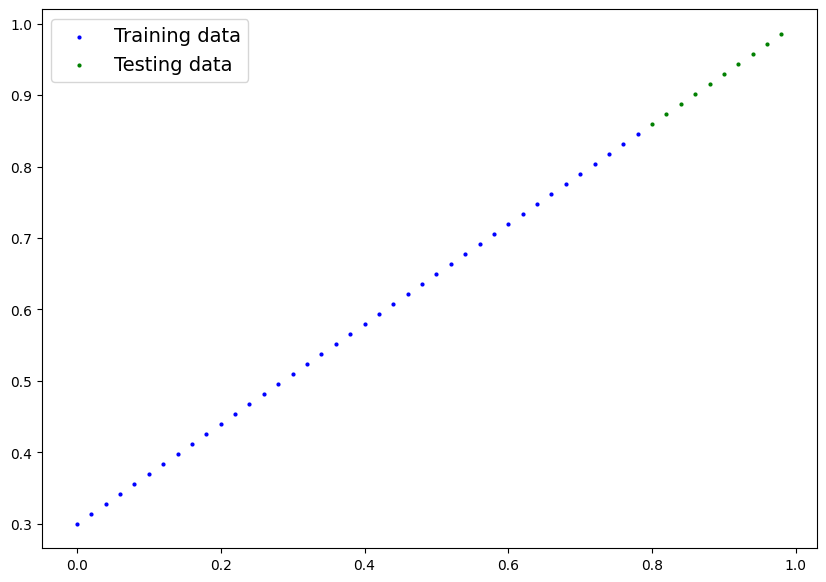

In [ ]:
plot_predictions();

# 2. Build model
Pytorch model !


A. What our model do?
* Start with random values(weights & values)

* Look at training data and ajust the random values to better reprsent (or get closer to) the ideal (weight & bias) values are used to create data



B. How does it do so?

Through two main algo:
1. Gradient desecent
2. Backpropagation

In [ ]:
from torch import nn
import torch

# Create linerar regression model class

class LinearRegressionModel(nn.Module): # <- almost everything in Pytorch inherits from nn.Module
    def __init__(self):
      super().__init__()
      self.weights = nn.Parameter(torch.rand((1,),
                                  requires_grad=True, dtype=torch.float) )

      self.bias = nn.Parameter(torch.rand((1,),
                              requires_grad=True, dtype=torch.float))

    def forward(self, x: torch.Tensor) -> torch.Tensor: #  <- "x" is the input data
      return self.weights*x+self.bias  # this is the linear regression formula


### Pytorch model building essentials

* torch.nn - conatins all of the building blocks for the computational graphs(another word for neural networks can be considered computational graph )

* torch.nn.Parameters - what parameters should our model try and learn, often a Pytorch layer from torch.nn will set these for us

* torch.nn.Module - The base class for all neural network module, if you have subclass it, you should  overwrite forward ()

* torch.optim - this is optimizers in pytorch live they will help with gradient descent. HOw to improve gradient descent and in turn how to reduce loss

* def forward() - All nn.Module subclasses require you to overwrite forward(), this method defines what happens in forward computation.

* torch.utils.data.Dataset - Reprsent a map between key (label) and simple (features) pairs of your data. Such as images and their associated labels

* torch.utils.data.DataLoader - Allows you to iterate over you data

torchvision - Pytorch compuitation module

1. Get data ready and convert into tensor
 a. torchvision.transforms
 b. torch.utils.data.Dataset
 c. torch.utils.data.DataLoader

2. Building a model

 a. torch.nn.
 b. torch.nn.Module
 c. torchvision.models

2.1 optimizer - torch.optim

4. Evaluate the model

a. torchmetrics

5. Improve through experimentation

 a. torch.utils.tensorboard

# Checking the contents of  Pytorch Model

Now we've created a model, let's see what's inside...

So we can check our model parameters or what's inside our model using
.parameters()

In [ ]:
# Create a random seed
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module)
model_0 = LinearRegressionModel()

list(model_0.parameters())

[Parameter containing:
 tensor([0.8823], requires_grad=True),
 Parameter containing:
 tensor([0.9150], requires_grad=True)]

In [ ]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([0.9150]))])

## Making predictions using torch.inference_mode()

To check our model's predictive power, lets  see how well it predicts y_test based on x_test


when we pass our data, its going to run through the forward() method

In [ ]:
y_pred = model_0(x_test)
y_pred

tensor([[1.6208],
        [1.6385],
        [1.6561],
        [1.6738],
        [1.6914],
        [1.7090],
        [1.7267],
        [1.7443],
        [1.7620],
        [1.7796]], grad_fn=<AddBackward0>)

In [ ]:
# Making predictions with models
with torch.inference_mode():
   y_preds = model_0(x_test)

# You ca also do same thing with torch.no_grad(), however inference_mode() is preferred
with torch.no_grad():
  y_preds = model_0(x_test)
y_preds

tensor([[1.6208],
        [1.6385],
        [1.6561],
        [1.6738],
        [1.6914],
        [1.7090],
        [1.7267],
        [1.7443],
        [1.7620],
        [1.7796]])

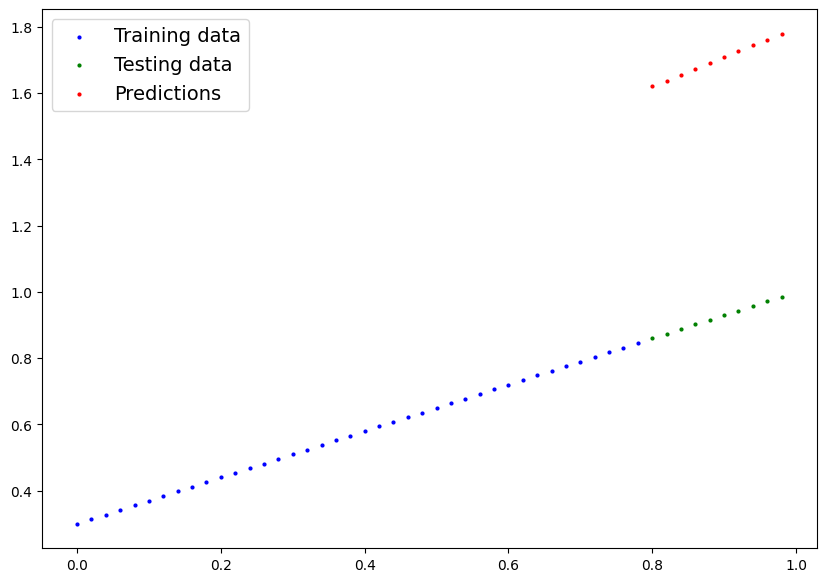

In [ ]:
plot_predictions(predictions=y_preds)

# 3. Train model
The whole idea of training is for a model to move from some *unknown* parameters (these may be random ) to some known parameters.

Or in other words from poor representaion to a better representation of the data.

One way to measure how poor or how wrong your models predictions are is to use loss function.

* Note: Loss function may also be called cost function or criterion in different areas. For our cases, we're going to refer to it as a loss function.

Things we need to train:

* **Loss function** : A  function to measures how wrong your model's predictions are to the ideal outputs, lower is better.
* **Optimizer**: Takes into account the loss of a model and adjusts the model's parameters (eg. weight & bias) to improve the loss function.

And spcifically for Pytorch we need:
* A training loop
* A testing loop

In [ ]:
# Checkout models parameters (a parameter is a value that the model sets itself)
list(model_0.parameters())

[Parameter containing:
 tensor([0.8823], requires_grad=True),
 Parameter containing:
 tensor([0.9150], requires_grad=True)]

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([0.9150]))])

In [ ]:
#Set up a loss function
loss_fn = nn.L1Loss()

# Smaller the learning rate small change in parameter, larger the learning rate larger change in parameter

# Set up an optimizer
optimizer = torch.optim.SGD(model_0.parameters(),
                            lr=0.01) # learning rate = possibly the most imp hyperparameter you can set

## Building a training loop (testing loop) in Pytorch

Steps required in a training loop:

0. Loop through the data
1. Forward pass (this involves data moving throughour model's forward() functions) to make predictions on data - also called forward propagation
2. Calculate the loss (compare forward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss backward - move backwards through the network to calculate the gradients of each of the parameters of our model with respect to the loss (**backpropagation**)
5. Optimizer step - use the optimizer to adjust our model's parameter to try and improve the loss
**(gradient descent)**

In [ ]:
with torch.no_grad():
  list(model_0.parameters())

In [ ]:
from numpy import test
# An epoch is one loop through the data...
epochs = 100

# Track different values
epoch_count = []
loss_values = []
test_loss_values = []

# 0. Loop through the data
# Pass the data through the model for a number of epochs
for epoch in range(epochs):

    #Set the model to training mode
    model_0.train() #train mode in Pytorch set

# 1. Forward pass
# pass the data through the model, this will perform the forward() method located within the model object

    y_pred = model_0(x_train)

# 2. Calculate the loss (how wrong the model's prediction are)
    loss = loss_fn(y_pred, y_train)

#3. Optimize zero grad (they accumulate every epoach, zero them to start fresh each forward passs )
    optimizer.zero_grad()

# 4. Perform backpropagation on the loss with respect to the parameters of the model (computes the gradient of every parameter with requires_grad=True)
    loss.backward()

# 5. Step the optimizer (perform gradient descent)
    optimizer.step()

# by default how the optimizer changes will accumulate through the loop, so we have to zero them in step 3 for the next iteration of the loop


### Testing

    model_0.eval() #turns off different settings in model not needed for evaluation/testing

    with torch.inference_mode():
        test_pred = model_0(x_test)
        test_loss = loss_fn(test_pred, y_test)

    # Print every 10 epochs
    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss.item())
        test_loss_values.append(test_loss.item())
        print(f"Epoch: {epoch} | Train loss: {loss.item()} | Test loss: {test_loss.item()}")

# After training
print(model_0.state_dict())




Epoch: 0 | Train loss: 0.6860889196395874 | Test loss: 0.7637526988983154
Epoch: 10 | Train loss: 0.5708791017532349 | Test loss: 0.6290428042411804
Epoch: 20 | Train loss: 0.45566922426223755 | Test loss: 0.4943329691886902
Epoch: 30 | Train loss: 0.34045934677124023 | Test loss: 0.35962313413619995
Epoch: 40 | Train loss: 0.2252494841814041 | Test loss: 0.2249133139848709
Epoch: 50 | Train loss: 0.1100396141409874 | Test loss: 0.09020347893238068
Epoch: 60 | Train loss: 0.009724985808134079 | Test loss: 0.020998019725084305
Epoch: 70 | Train loss: 0.006216754671186209 | Test loss: 0.014099234715104103
Epoch: 80 | Train loss: 0.002788322512060404 | Test loss: 0.005826681852340698
Epoch: 90 | Train loss: 0.007095950655639172 | Test loss: 0.00754010071977973
OrderedDict({'weights': tensor([0.6977]), 'bias': tensor([0.3080])})


Training loop song:
* Its train time!
* do the forward pass,
* calculate the loss,
* optimizer zero grad,
* loss backwards!
* optimizer step step step

In [ ]:
with torch.inference_mode(): # turns off gradient tracking & a couple of more things behined the scenes
# with torch.no_grad():
  y_pred_new = model_0(x_test)



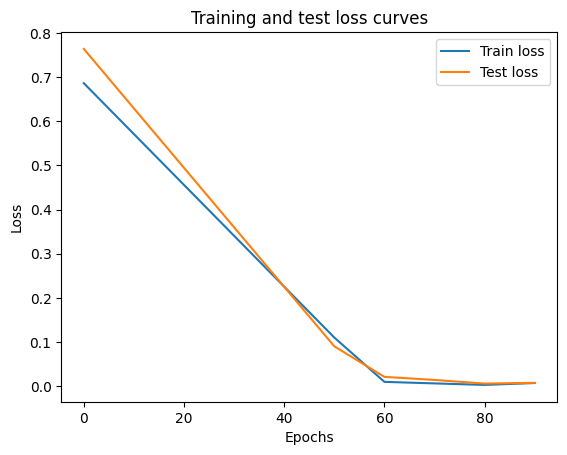

In [ ]:
# Plot the loss curves
plt.plot(epoch_count, loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

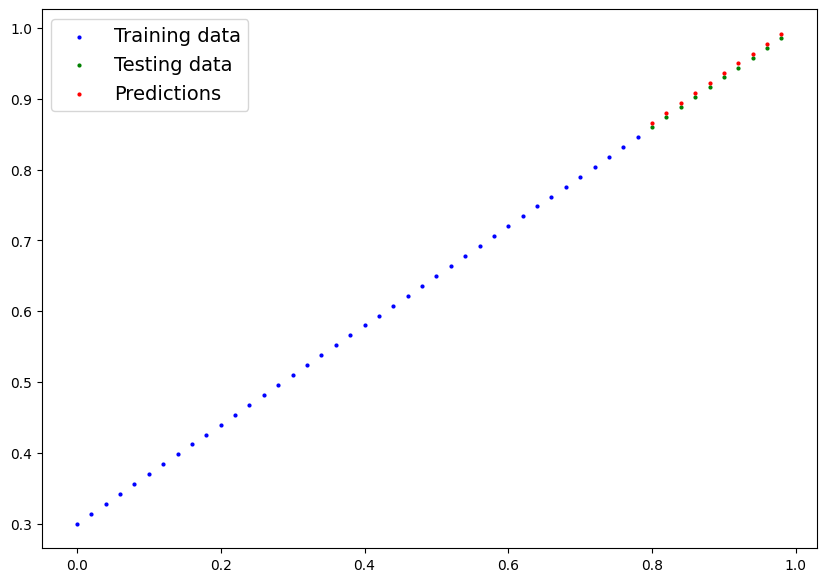

In [ ]:
plot_predictions(predictions=y_pred_new)

# Saving a model

There are three methods for saving and loading models in Pytorch.

1. `torch.save()` - allows you save a Pytorch object in Python pickle format. Pickle helps in serializing(saving) and deserializing(loading) object.
2. `torch.nn.Module.load_state_dict()` - this allows to load a model's saved state dictionary .

3. `torch.load()` - this allows you load a saved Pytorch object

In [ ]:
#Saving our Pytorch model
from pathlib import Path

#1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

#2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

MODEL_SAVE_PATH

#Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(),
           f=MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model_0.pth


In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6977])), ('bias', tensor([0.3080]))])

# Loading a Pytorch model

Since we saved our model's `state_dict()` rather than entire model, we'll create a new instance of our model class and load the  saved `state_dict()` into that.

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6977])), ('bias', tensor([0.3080]))])

In [ ]:
# To load in a saved state_dict we have to instantiate a new instance of our model class
loaded_model_0 = LinearRegressionModel()

# Load the saved state_dict of model_0(this will update with the new instance with the updated parameters)

loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [ ]:
loaded_model_0 .state_dict()

OrderedDict([('weights', tensor([0.6977])), ('bias', tensor([0.3080]))])

In [ ]:
# ake some predictions with our loaded model:
loaded_model_0.eval()
with torch.inference_mode():
   loaded_model_preds= loaded_model_0(x_test)

loaded_model_preds

tensor([[0.8661],
        [0.8801],
        [0.8940],
        [0.9080],
        [0.9220],
        [0.9359],
        [0.9499],
        [0.9638],
        [0.9778],
        [0.9917]])

In [ ]:
# Make some models preds
model_0.eval()
with torch.inference_mode():
   y_preds= model_0(x_test)

y_preds

tensor([[0.8661],
        [0.8801],
        [0.8940],
        [0.9080],
        [0.9220],
        [0.9359],
        [0.9499],
        [0.9638],
        [0.9778],
        [0.9917]])

In [ ]:
# Compare loaded models preds with original model preds
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

#Revision sort of


In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt

# Checking pytorch version
torch.__version__

'2.10.0+cpu'

#Create device-agnosyic code.

This means if we've got access to a GPU, Our code will use it (for potentially faster computation).

If no GPU is available, the code will default to using CPU

In [ ]:
# Setup device agaonistic code

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device : {device}")

Using device : cpu


In [ ]:
# Create some data using linear regression formula
weight =0
bias = 0.3

# Create a range values
start =0
end=1
step=0.02

# create x and y
x = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight*x+bias
x[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3000],
         [0.3000],
         [0.3000],
         [0.3000],
         [0.3000],
         [0.3000],
         [0.3000],
         [0.3000],
         [0.3000]]))

In [ ]:
# Spliting some data
train_split = int(0.8*len(x))
x_train, y_train = x[:train_split],y[:train_split]
x_test,y_test = x[train_split:], y[train_split:]
len(x_train), len(y_train), len(x_test), len(y_test)
# x_test,y_test

(40, 40, 10, 10)

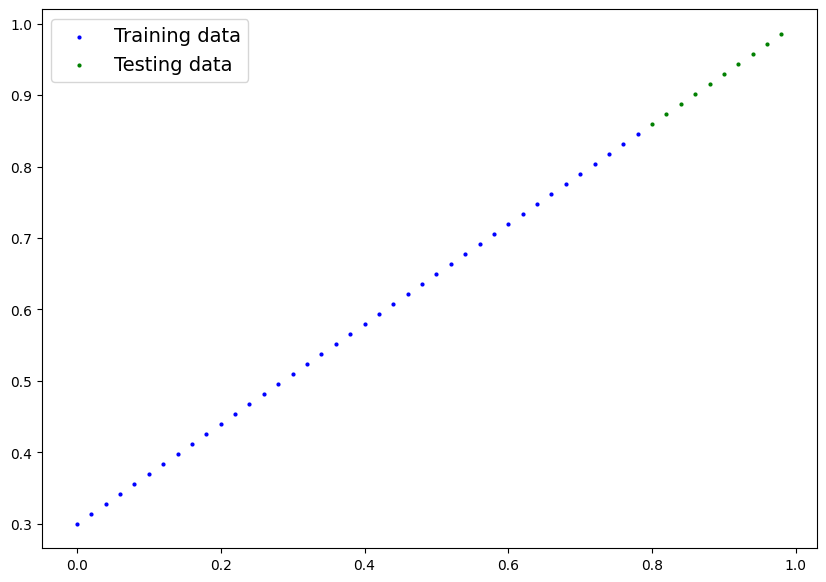

In [ ]:
plot_predictions()

# Building a Pytorch model

In [ ]:
from torch import nn
import torch

# Create a Linear model by subclassing nn.Module
class LinearRegressionModelV2(nn.Module):
   def __init__(self):
      super().__init__()
     # Use nn.Linear() for creating model performance
      self.linear_layer = nn.Linear(in_features=1,
                                  out_features=1)
   def forward(self,x: torch.Tensor) -> torch.Tensor:
       return self.linear_layer(x)

#Set the manual seed
torch.manual_seed(42)
model_1=LinearRegressionModelV2()
model_1,model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [ ]:
# Check the model current device
next(model_1.parameters()).device

device(type='cpu')

In [ ]:
model_1.to(device)
next(model_1.parameters()).device

device(type='cpu')

In [ ]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

# 6.3 Training
For training we need:

  * Loss Function
  * Optimizer
  * Training loop
  * Testing loop

In [ ]:
# Setup loss function
loss_fn = nn.L1Loss() # same as MAE

# Setup our optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.01)

In [ ]:
# Let's write a training loop
torch.manual_seed(42)

epochs=200

# put data on the target devioce (device agonistic code for data)
x_train = x_train.to(device)
y_train = y_train.to(device)
x_test = x_test.to(device)
y_test = y_test.to(device)


for epoch in range(epochs):
  model_1.train()

  #1. Forward pass
  y_pred = model_1(x_train)

  #2. Calculate the loss
  loss = loss_fn(y_pred,y_train)

  #3. Optimizer zero grad
  optimizer.zero_grad()

  #4. Perform backpropgation
  loss.backward()

  #5. Optimizer step by step
  optimizer.step()


##Testing
  model_1.eval()
  with torch.inference_mode():
   test_pred = model_1(x_test)

   test_loss = loss_fn(test_pred,y_test)

  if epoch %10==0:
    print(f"Epoach: {epoch} | Loss: {loss} | Test loss: {test_loss}")


Epoach: 0 | Loss: 0.8281779289245605 | Test loss: 1.1969763040542603
Epoach: 10 | Loss: 0.712968111038208 | Test loss: 1.06226646900177
Epoach: 20 | Loss: 0.5977581739425659 | Test loss: 0.9275565147399902
Epoach: 30 | Loss: 0.4825482964515686 | Test loss: 0.7928466796875
Epoach: 40 | Loss: 0.3673384189605713 | Test loss: 0.6581368446350098
Epoach: 50 | Loss: 0.252128541469574 | Test loss: 0.5234270691871643
Epoach: 60 | Loss: 0.15707053244113922 | Test loss: 0.40211763978004456
Epoach: 70 | Loss: 0.11480660736560822 | Test loss: 0.3197880685329437
Epoach: 80 | Loss: 0.0968836173415184 | Test loss: 0.2657199501991272
Epoach: 90 | Loss: 0.08862494677305222 | Test loss: 0.23072807490825653
Epoach: 100 | Loss: 0.0838618129491806 | Test loss: 0.20891353487968445
Epoach: 110 | Loss: 0.08003319799900055 | Test loss: 0.19382549822330475
Epoach: 120 | Loss: 0.07654319703578949 | Test loss: 0.1828053891658783
Epoach: 130 | Loss: 0.07305320352315903 | Test loss: 0.17178533971309662
Epoach: 140 |

In [ ]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.2436]])),
             ('linear_layer.bias', tensor([0.1975]))])

In [ ]:
weight, bias

(0, 0.3)

# Making and evaluating predictions

In [ ]:
#Turn models into evaluation mode
model_1.eval()

# Make prediction on the test data
with torch.inference_mode():
   y_preds = model_1(x_test)

y_preds

tensor([[0.3924],
        [0.3972],
        [0.4021],
        [0.4070],
        [0.4119],
        [0.4167],
        [0.4216],
        [0.4265],
        [0.4313],
        [0.4362]])

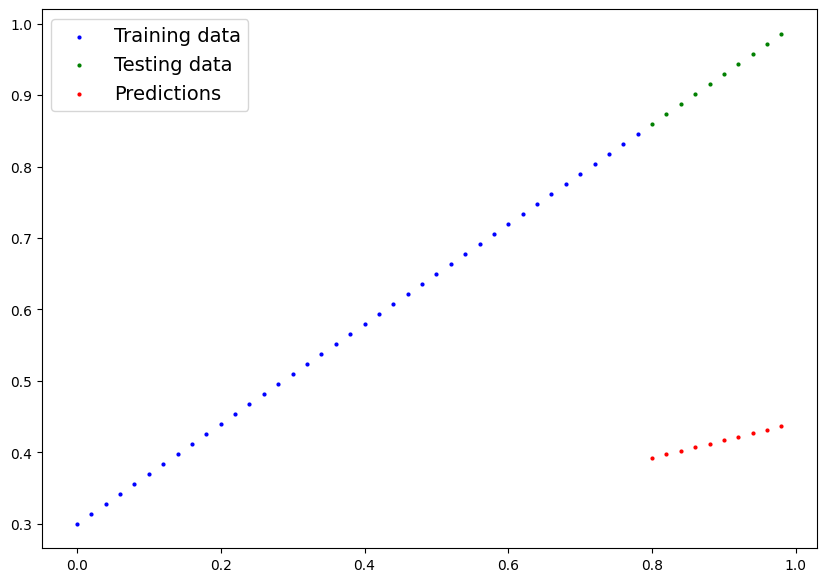

In [ ]:
# Check out our model predictions visually
plot_predictions(predictions=y_preds.cpu())

In [ ]:
# Saving and loading a Pytorch model
from pathlib import Path

#1. Create models directory
